<a href="https://colab.research.google.com/github/KeyHornO/Machine-Learning/blob/main/Week3_Thermoelectric_SnSe_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: Problem, Data and ML Workflow
## Predicting How Processing and Texture Control the Thermoelectric Performance of Polycrystalline SnSe

**Name:** Njuguna Benson

**Course project repo:** https://github.com/KeyHornO/Machine-Learning

---
## 1. Project problem and intended AI/ML outcome

**Problem.** Polycrystalline SnSe performs worse than single-crystal SnSe mainly because of weak **(h00) crystallographic texture**, which lowers carrier mobility and electrical conductivity. In my published work, I used **hot extrusion (HE)** to improve texture in bulk SnSe made by mechanical alloying. Raising the extrusion temperature from 350 °C to 500 °C raised the (h00) orientation factor from 0.44 to 0.55 and doubled Hall mobility (8.48 to 15.19 cm²/Vs). However, HE also coarsened the grains and increased thermal conductivity, so the 350 °C-HE sample reached zT = 0.64 at 772 K, while the 500 °C spark-plasma-sintered (SPS) sample reached a higher zT = 0.83.

So there is a trade-off: **texture and mobility go up, but grain coarsening raises thermal conductivity.** Finding the processing window that balances them by trial and error means many costly synthesis and measurement cycles.

**Intended AI/ML outcome.** A supervised **regression** model that predicts thermoelectric properties (carrier mobility, thermal conductivity and **zT**) of polycrystalline SnSe from its **processing conditions and microstructure** (process type, temperature, texture factor, grain size, carrier density). The model will suggest which processing conditions are most promising to try next, so fewer samples have to be made.

> Long-term extension: add dopants and composition as inputs, to also address n-type SnSe.

### Key results from my PhD thesis – context for the ML problem

**Samples.** SnSe powder made by mechanical alloying (12 h), then consolidated by **hot extrusion (HE)** at 350, 400, 450 and 500 °C (extrusion ratio 14:1, 1 mm/min), or by **spark plasma sintering (SPS)** at 450–600 °C (50 MPa, 15 °C/min, 5 min soak).

- **Texture (Lotgering (h00) orientation factor):** HE rises from 0.34 (350 °C) to 0.47 (500 °C), driven by severe plastic deformation and grain rotation. SPS peaks near 0.28 at 400 °C, then falls to 0.17 at 600 °C.
- **Grain size:** SPS grows from 0.28 µm (450 °C) to 1.5 µm (600 °C). HE at 500 °C is about 1.3 µm, roughly 3.7 times the SPS value at 500 °C.
- **Hall carrier density:** HE rises from 5.6 × 10¹⁵ to 1.3 × 10¹⁸ cm⁻³ (about 230×) between 350 and 500 °C. SPS rises from 1.3 × 10¹⁸ (450 °C) to 4.5 × 10¹⁸ cm⁻³ (600 °C). All samples are p-type.
- **Hall mobility:** HE rises from 8.5 to 15.2 cm²/Vs with extrusion temperature, even though carrier density also rises (normally the two trade off). SPS falls from 9.8 to 2.3 cm²/Vs with sintering temperature, following the loss of texture. Texture reduces grain-boundary scattering, and higher temperature adds intrinsic acceptor-like defects (Sn vacancies, antisite defects).
- **Weighted mobility** rises with extrusion temperature, which suggests band convergence.
- **Transport regimes (both routes):** grain-boundary thermally activated transport (300–400 K), acoustic phonon scattering (400–600 K), intrinsic bipolar conduction (above about 600 K). Band gap about 0.46–0.49 eV (0.42 eV for HE at 500 °C).
- **Thermal conductivity at 300 K (W/m·K):** HE 1.11, 1.34, 1.41, 1.34 for 350–500 °C. SPS 1.07, 1.21, 1.01, 1.30 for 450–600 °C.
- **zT at 772 K:** HE about 0.64 (350 °C) down to about 0.56–0.59 at higher temperatures. SPS 0.70 (450 °C), **0.83 (500 °C, best)**, 0.52 (550 °C), 0.47 (600 °C).
- **Trade-off:** HE gives higher power factor through better texture, but coarser grains raise κ, so zT does not improve. Future work: hybrid or post-processing to combine strong texture with fine grains, which is the optimisation the ML model should support.

## 2. Data I would need

| Data | Role | Where it can come from |
|---|---|---|
| Composition (host, dopants, alloying) | Input | Public TE databases, literature |
| Measurement temperature | Input | Public TE databases |
| Process type and temperature (HE, SPS, hot press) | Input | **My lab records only** (not in public databases) |
| (h00) orientation factor, grain size | Input (microstructure) | **My XRD/SEM only** |
| Hall carrier density and mobility | Input or target | My Hall data, some literature |
| Seebeck S, electrical conductivity σ, thermal conductivity κ | Target | Public TE databases, my lab |
| zT versus temperature | Main target | Public TE databases, my lab |

**The central data gap.** Public databases give composition, temperature and transport properties, but not texture, grain size or processing route, which are exactly what my paper is about. My own HE/SPS samples have those, but there are very few. So the plan is a **two-level approach**: (1) use a public experimental database to learn how composition and temperature relate to S, σ, κ and zT for SnSe-based materials, and (2) bring in my own processing and microstructure data to model the texture–grain-size trade-off.

### 2a. My own data

In [75]:
import pandas as pd, numpy as np

nan = np.nan
my_data = pd.DataFrame([
 # process, temp_C, h00 (Fig 2.4), h00 stated in Conclusions, grain_um, nH_cm3, muH, kappa_300K, zT_772K
 ["HE",  350, 0.338, 0.44, nan,  5.58e15, 8.48,  1.11, 0.64],
 ["HE",  400, 0.361, nan,  nan,  2.8e16,  9.61,  1.34, 0.56],   # nH low-precision (read from plot); zT approx (curves overlap)
 ["HE",  450, 0.365, nan,  nan,  9.4e17,  11.98, 1.41, 0.56],   # zT approx (curves overlap)
 ["HE",  500, 0.472, 0.55, 1.31, 1.29e18, 15.19, 1.34, 0.59],
 ["SPS", 350, 0.252, nan,  nan,  nan,     nan,   nan,  nan ],
 ["SPS", 400, 0.280, 0.40, nan,  nan,     nan,   nan,  nan ],
 ["SPS", 450, 0.274, nan,  0.28, 1.25e18, 9.80,  1.07, 0.70],
 ["SPS", 500, 0.236, nan,  0.33, 1.56e18, 9.70,  1.21, 0.83],
 ["SPS", 550, 0.205, nan,  0.70, 4.14e18, 7.74,  1.01, 0.52],
 ["SPS", 600, 0.166, 0.25, 1.50, 4.45e18, 2.31,  1.30, 0.47],
], columns=["process", "temp_C", "h00_factor", "h00_stated_in_conclusions", "grain_size_um",
            "carrier_density_cm3", "mobility_cm2Vs", "kappa_300K_W_mK", "zT_772K"])

my_data

,process,temp_C,h00_factor,h00_stated_in_conclusions,grain_size_um,carrier_density_cm3,mobility_cm2Vs,kappa_300K_W_mK,zT_772K
0,HE,350,0.338,0.44,NaN,5.580000e+15,8.48,1.11,0.64
1,HE,400,0.361,NaN,NaN,2.800000e+16,9.61,1.34,0.56
2,HE,450,0.365,NaN,NaN,9.400000e+17,11.98,1.41,0.56
3,HE,500,0.472,0.55,1.31,1.290000e+18,15.19,1.34,0.59
4,SPS,350,0.252,NaN,NaN,NaN,NaN,NaN,NaN
5,SPS,400,0.280,0.40,NaN,NaN,NaN,NaN,NaN
6,SPS,450,0.274,NaN,0.28,1.250000e+18,9.80,1.07,0.70
7,SPS,500,0.236,NaN,0.33,1.560000e+18,9.70,1.21,0.83
8,SPS,550,0.205,NaN,0.70,4.140000e+18,7.74,1.01,0.52
9,SPS,600,0.166,0.25,1.50,4.450000e+18,2.31,1.30,0.47


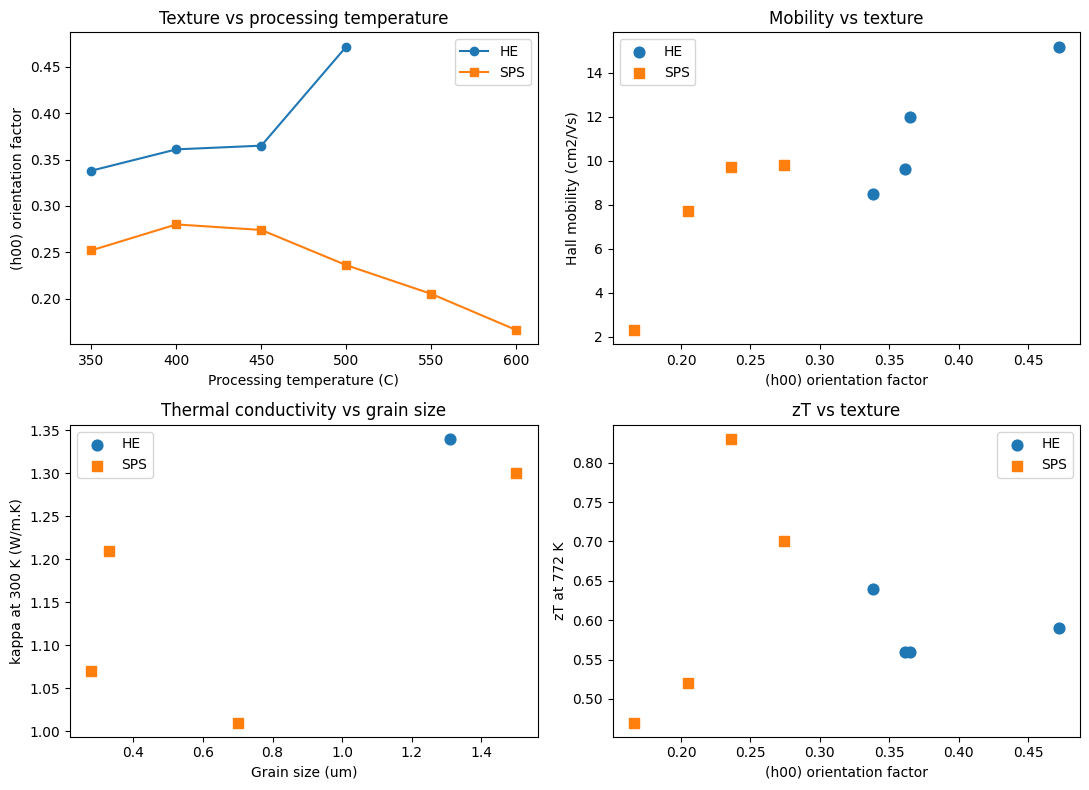

In [76]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for proc, mk in [("HE", "o"), ("SPS", "s")]:
    d = my_data[my_data.process == proc]
    ax[0,0].plot(d.temp_C, d.h00_factor, marker=mk, label=proc)
    ax[0,1].scatter(d.h00_factor, d.mobility_cm2Vs, marker=mk, s=60, label=proc)
    ax[1,0].scatter(d.grain_size_um, d.kappa_300K_W_mK, marker=mk, s=60, label=proc)
    ax[1,1].scatter(d.h00_factor, d.zT_772K, marker=mk, s=60, label=proc)
ax[0,0].set(xlabel="Processing temperature (C)", ylabel="(h00) orientation factor", title="Texture vs processing temperature")
ax[0,1].set(xlabel="(h00) orientation factor", ylabel="Hall mobility (cm2/Vs)", title="Mobility vs texture")
ax[1,0].set(xlabel="Grain size (um)", ylabel="kappa at 300 K (W/m.K)", title="Thermal conductivity vs grain size")
ax[1,1].set(xlabel="(h00) orientation factor", ylabel="zT at 772 K", title="zT vs texture")
for a in ax.ravel(): a.legend()
plt.tight_layout(); plt.show()

### 2c. My own temperature-dependent data



In [77]:
import io
CSV = """process,temp_C,T_K,sigma_S_m,seebeck_uV_K,kappa_W_mK,zT,zT_from_sigma_S_kappa,low_confidence
HE,350,298,461,434.3,1.111,0.014,0.023,True
HE,350,372,854,460.4,0.931,0.077,0.072,True
HE,350,472,810,478.4,0.74,0.115,0.118,True
HE,350,572,698,472.8,0.64,0.128,0.139,True
HE,350,622,788,454.3,0.614,0.154,0.165,True
HE,350,672,1122,419.0,0.566,0.254,0.234,False
HE,350,722,2011,382.3,0.55,0.42,0.386,False
HE,350,772,3680,345.5,0.543,0.628,0.625,False
HE,400,298,398,431.6,1.344,0.004,0.016,False
HE,400,372,763,456.6,1.089,0.063,0.054,True
HE,400,472,900,472.1,0.846,0.1,0.112,False
HE,400,572,785,461.8,0.729,0.122,0.131,True
HE,400,622,857,441.9,0.691,0.15,0.15,True
HE,400,672,1337,424.6,0.636,0.255,0.255,True
HE,400,722,1851,399.3,0.606,0.352,0.352,True
HE,400,772,3477,358.9,0.631,0.557,0.547,True
HE,450,298,716,420.4,1.405,0.013,0.027,True
HE,450,372,1110,439.5,1.111,0.075,0.072,False
HE,450,472,1009,464.0,0.826,0.113,0.124,True
HE,450,572,813,457.0,0.782,0.152,0.124,True
HE,450,622,871,444.4,0.739,0.145,0.145,True
HE,450,672,1198,428.7,0.695,0.231,0.213,True
HE,450,722,1930,395.6,0.652,0.36,0.334,True
HE,450,772,3579,353.1,0.609,0.566,0.566,True
HE,500,298,988,402.9,1.287,0.026,0.037,True
HE,500,372,1541,421.7,1.044,0.094,0.098,True
HE,500,472,1300,442.5,0.804,0.132,0.15,True
HE,500,572,953,424.9,0.684,0.135,0.144,True
HE,500,622,968,413.8,0.653,0.154,0.158,True
HE,500,672,1275,402.6,0.665,0.216,0.209,True
HE,500,722,1933,381.5,0.668,0.343,0.304,True
HE,500,772,3579,354.3,0.594,0.579,0.584,True
SPS,450,298,432,388.2,1.081,0.02,0.018,True
SPS,450,372,1130,409.0,0.813,0.086,0.087,True
SPS,450,472,1209,428.5,0.648,0.181,0.162,True
SPS,450,572,897,425.5,0.521,0.197,0.178,False
SPS,450,622,866,410.2,0.447,0.228,0.203,True
SPS,450,672,1107,394.9,0.41,0.334,0.283,True
SPS,450,722,1798,378.4,0.37,0.439,0.503,True
SPS,450,772,2995,345.8,0.338,0.7,0.817,True
SPS,500,298,521,385.6,1.217,0.02,0.019,True
SPS,500,372,1244,402.0,0.897,0.086,0.083,True
SPS,500,472,1360,424.0,0.781,0.139,0.148,True
SPS,500,572,994,422.6,0.666,0.192,0.153,True
SPS,500,622,1078,422.8,0.55,0.245,0.218,True
SPS,500,672,1200,407.4,0.434,0.298,0.308,True
SPS,500,722,2221,371.0,0.397,0.499,0.556,True
SPS,500,772,3160,337.5,0.374,0.826,0.743,True
SPS,550,298,611,357.3,1.017,0.027,0.023,True
SPS,550,372,1507,380.4,0.796,0.103,0.102,True
SPS,550,472,1532,406.8,0.571,0.211,0.21,True
SPS,550,572,1079,420.9,0.503,0.214,0.217,False
SPS,550,622,976,418.4,0.503,0.207,0.211,False
SPS,550,672,1050,404.4,0.48,0.246,0.24,False
SPS,550,722,1623,383.5,0.491,0.345,0.351,False
SPS,550,772,2706,346.2,0.488,0.521,0.513,False
SPS,600,298,521,312.9,1.3,0.012,0.012,False
SPS,600,372,1439,340.8,0.949,0.068,0.066,False
SPS,600,472,1603,380.3,0.776,0.152,0.141,True
SPS,600,572,1222,393.4,0.602,0.177,0.18,False
SPS,600,622,1124,397.0,0.588,0.187,0.187,False
SPS,600,672,1112,393.1,0.551,0.218,0.21,False
SPS,600,722,1717,375.8,0.54,0.309,0.324,False
SPS,600,772,2954,353.8,0.563,0.471,0.507,False"""

temp_data = pd.read_csv(io.StringIO(CSV))

# join the per-sample features (texture, grain size, carrier density, mobility) from section 2a
static = my_data[["process", "temp_C", "h00_factor", "grain_size_um", "carrier_density_cm3", "mobility_cm2Vs"]]
my_full = temp_data.merge(static, on=["process", "temp_C"], how="left")
my_full["sample"] = my_full["process"] + "-" + my_full["temp_C"].astype(str)

print("Shape:", my_full.shape, "| samples:", my_full["sample"].nunique())
my_full.head(10)

Shape: (64, 14) | samples: 8


,process,temp_C,T_K,sigma_S_m,seebeck_uV_K,kappa_W_mK,zT,zT_from_sigma_S_kappa,low_confidence,h00_factor,grain_size_um,carrier_density_cm3,mobility_cm2Vs,sample
0,HE,350,298,461,434.3,1.111,0.014,0.023,True,0.338,NaN,5.580000e+15,8.48,HE-350
1,HE,350,372,854,460.4,0.931,0.077,0.072,True,0.338,NaN,5.580000e+15,8.48,HE-350
2,HE,350,472,810,478.4,0.740,0.115,0.118,True,0.338,NaN,5.580000e+15,8.48,HE-350
3,HE,350,572,698,472.8,0.640,0.128,0.139,True,0.338,NaN,5.580000e+15,8.48,HE-350
4,HE,350,622,788,454.3,0.614,0.154,0.165,True,0.338,NaN,5.580000e+15,8.48,HE-350
5,HE,350,672,1122,419.0,0.566,0.254,0.234,False,0.338,NaN,5.580000e+15,8.48,HE-350
6,HE,350,722,2011,382.3,0.550,0.420,0.386,False,0.338,NaN,5.580000e+15,8.48,HE-350
7,HE,350,772,3680,345.5,0.543,0.628,0.625,False,0.338,NaN,5.580000e+15,8.48,HE-350
8,HE,400,298,398,431.6,1.344,0.004,0.016,False,0.361,NaN,2.800000e+16,9.61,HE-400
9,HE,400,372,763,456.6,1.089,0.063,0.054,True,0.361,NaN,2.800000e+16,9.61,HE-400


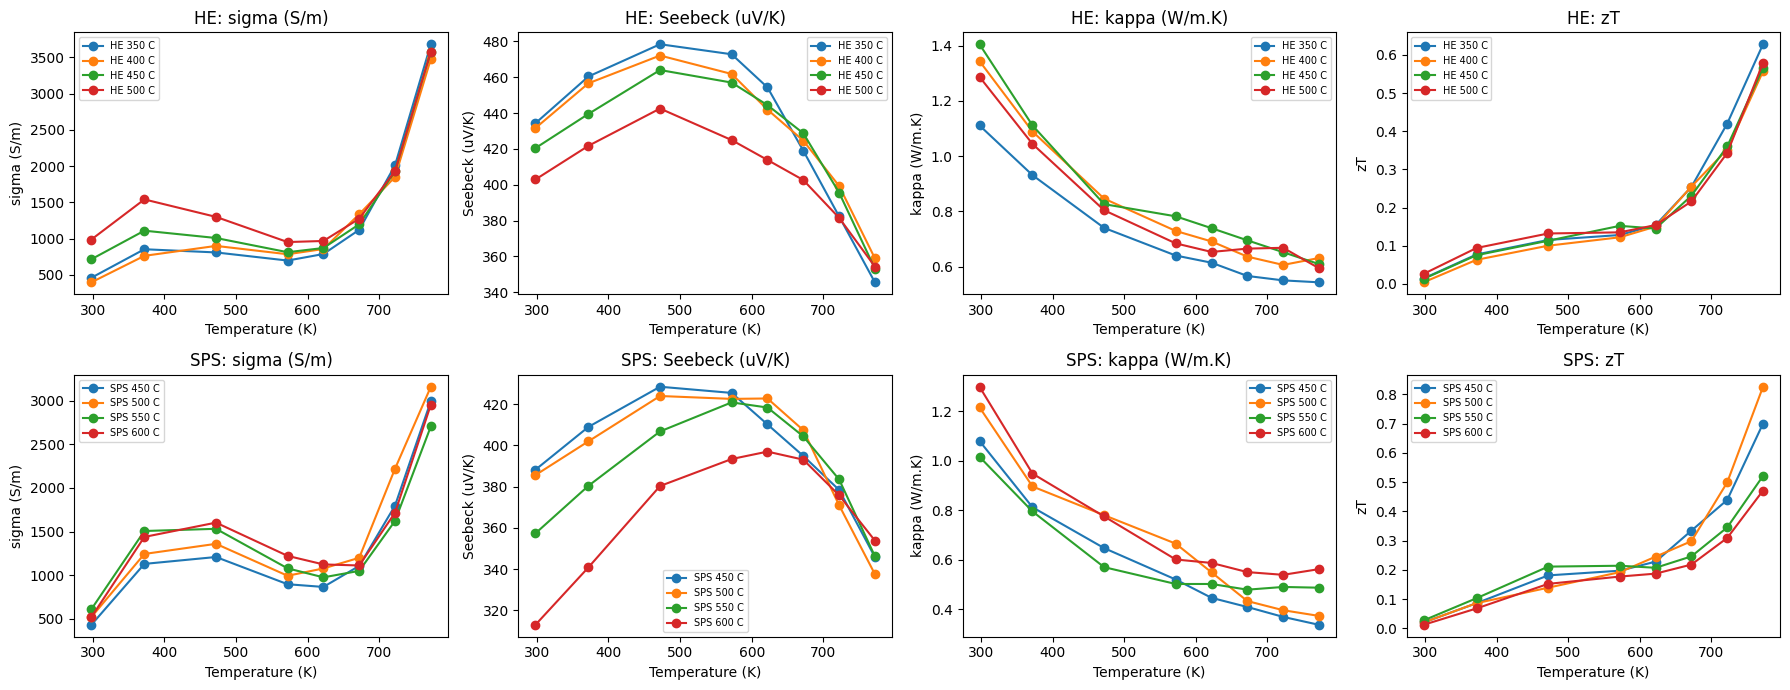

Mean |zT - zT_from_sigma_S_kappa| = 0.015


In [78]:
fig, ax = plt.subplots(2, 4, figsize=(18, 7))
cols = [("sigma_S_m", "sigma (S/m)"), ("seebeck_uV_K", "Seebeck (uV/K)"), ("kappa_W_mK", "kappa (W/m.K)"), ("zT", "zT")]
for r, proc in enumerate(["HE", "SPS"]):
    for k, (col, lab) in enumerate(cols):
        for s, g in my_full[my_full.process == proc].groupby("temp_C"):
            ax[r, k].plot(g["T_K"], g[col], marker="o", label=f"{proc} {s} C")
        ax[r, k].set(xlabel="Temperature (K)", ylabel=lab, title=f"{proc}: {lab}")
        ax[r, k].legend(fontsize=7)
plt.tight_layout(); plt.show()

# quick consistency check: zT (figure) vs zT computed from sigma, S, kappa
print("Mean |zT - zT_from_sigma_S_kappa| =", round((my_full.zT - my_full.zT_from_sigma_S_kappa).abs().mean(), 3))

### 2b. Public data sources considered

| Source | What it offers | Status in this notebook |
|---|---|---|
| **ESTM dataset** (Na & Chang, *npj Comput. Mater.* 2022; GitHub `KRICT-DATA/SIMD`) | 5,205 experimental observations, 880 materials: temperature, Seebeck, electrical conductivity, thermal conductivity, power factor, zT, source DOI | **Used below.** Contains SnSe-based materials |
| **Starrydata2** (starrydata2.org) | Largest open experimental TE collection (hundreds of thousands of points). Automatically extracted, with known errors, so it needs cleaning | Recommended next step to get more SnSe points; not loaded here |
| **teMatDb** (Ryu et al., GitHub `byungkiryu/teMatDb`, Zenodo) | 272 high-quality, self-consistent digitised TE curve sets from the literature | Repository is large (about 0.5 GB); candidate for later |
| **sysTEm** (ChemRxiv, 2025) | Over 8,400 verified experimental points, 1,400+ materials | Candidate for later |
| Kaggle, Zindi, Hugging Face | I searched for a ready-made thermoelectric or SnSe dataset on these and found none, so I used the scientific sources above | Check again if the course requires one of them |

I chose ESTM because it is experimental, tabular, already cleaned for machine learning, openly hosted, and loads directly into Colab with one line.

In [79]:
!pip install pymatgen -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.8/825.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.

In [80]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/KRICT-DATA/SIMD/main/dataset/estm.xlsx"
estm = pd.read_excel(URL)

# shorter column names
estm.columns = ["formula", "T_K", "seebeck_uV_K", "sigma_S_m", "kappa_W_mK", "pf_W_mK2", "zT", "doi"]

print("Shape (rows, columns):", estm.shape)
estm.head()

Shape (rows, columns): (5205, 8)


,formula,T_K,seebeck_uV_K,sigma_S_m,kappa_W_mK,pf_W_mK2,zT,doi
0,BiSb(Se0.92Br0.08)3,300.0,-110.0,27766.0,0.63,0.000336,0.159985,10.1002/adfm.201806558
1,BiSb(Se0.92Br0.08)3,400.0,-138.0,23883.0,0.57,0.000455,0.319177,10.1002/adfm.201806558
2,BiSb(Se0.92Br0.08)3,500.0,-163.0,20850.0,0.53,0.000554,0.522607,10.1002/adfm.201806558
3,BiSb(Se0.92Br0.08)3,600.0,-181.0,19000.0,0.51,0.000622,0.732305,10.1002/adfm.201806558
4,BiSb(Se0.92Br0.08)3,700.0,-193.0,17925.0,0.50,0.000668,0.940000,10.1002/adfm.201806558


In [81]:
estm.info()
estm.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5205 entries, 0 to 5204
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   formula       5205 non-null   object 
 1   T_K           5205 non-null   float64
 2   seebeck_uV_K  5205 non-null   float64
 3   sigma_S_m     5205 non-null   float64
 4   kappa_W_mK    5205 non-null   float64
 5   pf_W_mK2      5205 non-null   float64
 6   zT            5205 non-null   float64
 7   doi           5205 non-null   object 
dtypes: float64(6), object(2)
memory usage: 325.4+ KB


,count,mean,std,min,25%,50%,75%,max
T_K,5205.0,539.217533,1.924223e+02,1.000000e+01,392.000000,523.000000,673.000000,1.275000e+03
seebeck_uV_K,5205.0,73.183879,2.089242e+02,-1.174000e+03,-108.320000,100.690000,202.060000,1.052400e+03
sigma_S_m,5205.0,109584.461021,1.467224e+06,4.259000e-04,7059.000000,30200.000000,91795.000000,9.464455e+07
kappa_W_mK,5205.0,2.250818,3.290789e+00,7.000000e-02,0.734500,1.336300,2.694400,7.716000e+01
pf_W_mK2,5205.0,0.000992,1.123065e-03,2.079090e-11,0.000241,0.000626,0.001301,7.605400e-03
zT,5205.0,0.354195,3.475057e-01,4.603919e-10,0.078082,0.246795,0.534045,2.277911e+00


In [82]:
from pymatgen.core import Composition

def is_snse_based(formula):
    """SnSe-family: Sn and Se make up >=90% of atoms and Sn:Se is about 1:1."""
    try:
        amt = Composition(formula).get_el_amt_dict()
    except Exception:
        return False
    sn, se, total = amt.get("Sn", 0), amt.get("Se", 0), sum(amt.values())
    return sn > 0 and se > 0 and (sn + se) / total >= 0.9 and 0.8 <= sn / se <= 1.25

snse = estm[estm["formula"].apply(is_snse_based)].reset_index(drop=True)
print("SnSe-based rows:", len(snse), "| distinct compositions:", snse["formula"].nunique(),
      "| source papers:", snse["doi"].nunique())

snse.groupby("formula").agg(n_points=("zT", "size"), max_zT=("zT", "max"),
                            T_max_K=("T_K", "max")).sort_values("max_zT", ascending=False)

SnSe-based rows: 154 | distinct compositions: 16 | source papers: 6


,n_points,max_zT,T_max_K
formula,,,
SnSe,43,2.157625,873.0
Sn0.96Pb0.01Cd0.035Se,9,1.916585,873.0
Sn0.93Pb0.06Zn0.01Se,6,1.860000,773.0
Ag0.01Sn0.99Se0.85S0.15,8,1.556867,813.0
Sn0.96Pb0.03Zn0.01Se,6,1.516583,773.0
Sn0.965Pb0.01Cd0.025Se,9,1.504762,873.0
Sn0.97Pb0.01Cd0.025Se,9,1.245234,873.0
Ag0.01Sn0.99Se0.9S0.1,8,1.167104,813.0
Sn0.98Pb0.01Zn0.01Se,6,1.079288,773.0


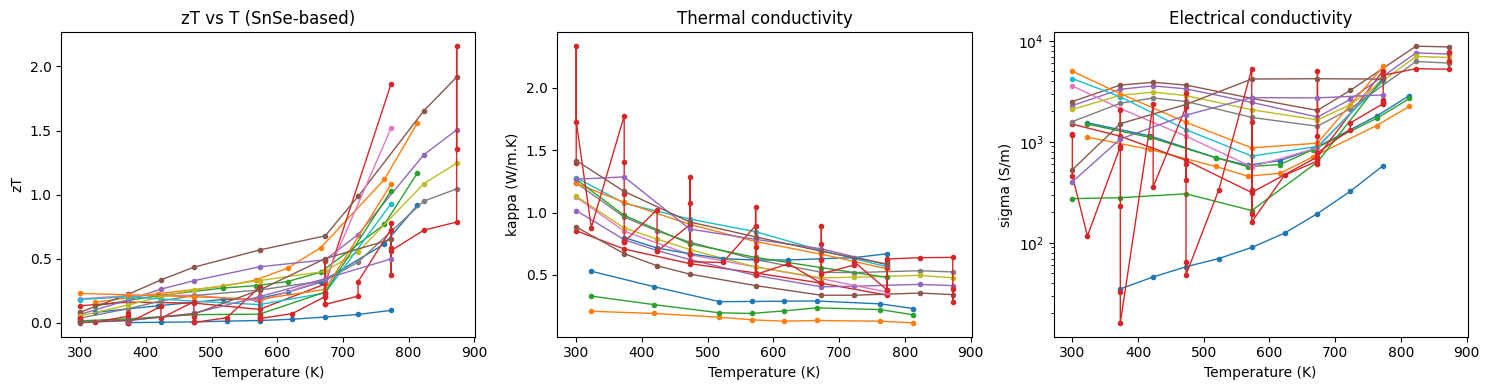

In [83]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for f, g in snse.groupby("formula"):
    g = g.sort_values("T_K")
    ax[0].plot(g["T_K"], g["zT"], marker=".", lw=1)
    ax[1].plot(g["T_K"], g["kappa_W_mK"], marker=".", lw=1)
    ax[2].plot(g["T_K"], g["sigma_S_m"], marker=".", lw=1)
ax[0].set(xlabel="Temperature (K)", ylabel="zT", title="zT vs T (SnSe-based)")
ax[1].set(xlabel="Temperature (K)", ylabel="kappa (W/m.K)", title="Thermal conductivity")
ax[2].set(xlabel="Temperature (K)", ylabel="sigma (S/m)", title="Electrical conductivity", yscale="log")
plt.tight_layout(); plt.show()

## 3. Inputs (features) and output (target)

**Public data (ESTM) – what is available now**

| | Variables |
|---|---|
| **Inputs (X)** | Composition, encoded as element fractions (Sn, Se, Pb, Cd, Zn, Ag, S, ...), and measurement temperature `T_K` |
| **Output (y)** | Main: **`zT`**. Secondary: `seebeck_uV_K`, `sigma_S_m`, `kappa_W_mK`, `pf_W_mK2` |

**My own data – what I add**

| | Variables |
|---|---|
| **Extra inputs** | `process` (HE or SPS), processing temperature, (h00) orientation factor, grain size, Hall carrier density, Hall mobility, and measurement temperature `T_K` (8 values, 298–772 K) |
| **Targets** | zT (at each temperature), thermal conductivity κ, electrical conductivity σ, Seebeck S, mobility |

Processing settings that were **held fixed** in my experiments (12 h milling at 200 rpm, ball-to-powder ratio 20:1, extrusion ratio 14:1, extrusion rate 1 mm/min, SPS pressure 50 MPa, heating rate 15 °C/min, soak 5 min) cannot be learned from my data, but would become useful inputs once literature data with different settings is added.

**Observed in my data:** mobility tracks texture closely (HE up, SPS down), grain size drives κ, and zT is a trade-off between the two. These are the relationships the model should learn.

**Task type:** supervised regression (zT can also be turned into a "high zT or not" classification for screening).



In [84]:
# ---- Inputs and target for the public data: element fractions + temperature ----
def element_fractions(formula):
    amt = Composition(formula).get_el_amt_dict()
    tot = sum(amt.values())
    return {el: v / tot for el, v in amt.items()}

frac = pd.DataFrame([element_fractions(f) for f in snse["formula"]]).fillna(0.0)
X = pd.concat([frac, snse[["T_K"]]], axis=1)
y = snse["zT"]

print("X shape:", X.shape, "| y shape:", y.shape)
print("Input features:", list(X.columns))
X.head()

X shape: (154, 9) | y shape: (154,)


TypeError: 'list' object is not callable

In [ ]:
# ---- Planned inputs/target for MY SnSe processing data (to be completed from lab records) ----
planned_X = ["process", "temp_C", "h00_factor", "grain_size_um", "carrier_density_cm3", "mobility_cm2Vs"]
planned_y = "zT_772K"
my_data[planned_X + [planned_y]]

## 4. Proposed ML workflow

```
 +------------------------+    +------------------------+    +--------------------------+
 | 1. DATA COLLECTION     | -> | 2. DATA CLEANING       | -> | 3. FEATURE ENGINEERING   |
 | ESTM (public) + my     |    | unify units, filter    |    | element fractions, T,    |
 | HE/SPS samples;        |    | SnSe-based rows, flag  |    | process type, texture,   |
 | Starrydata later       |    | missing, log-scale     |    | grain size               |
 +------------------------+    +------------------------+    +------------+-------------+
                                                                          |
                                                                          v
 +------------------------+    +------------------------+    +--------------------------+
 | 6. EVALUATION          | <- | 5. MODEL TRAINING      | <- | 4. VALIDATION SPLIT      |
 | R2, MAE, parity plot,  |    | linear / ridge baseline|    | leave-one-out or k-fold  |
 | uncertainty            |    | random forest, GP      |    | (small dataset)          |
 +-----------+------------+    +------------------------+    +--------------------------+
             |
             v
 +------------------------+    +-----------------------------------------+
 | 7. INTERPRET           | -> | 8. RECOMMEND AND TEST                   |
 | which factor drives zT:|    | suggest next HE/SPS temperatures; make  |
 | texture, grain size?   |    | and measure samples; add to the dataset |
 +------------------------+    +-----------------------------------------+
```

** Explanation**
1. **Collect:** the public ESTM experimental database for composition and temperature trends, plus my own HE and SPS measurements for texture and microstructure.
2. **Clean:** align units (cm²/Vs, W/m·K), handle missing values, and make one row per sample and measurement temperature.
3. **Features:** encode process type, add temperature, texture factor and grain size, and composition descriptors when dopants are included.
4. **Validation:** group splits by source paper (`doi`) so the model is tested on papers it has not seen; with my own tiny dataset, use leave-one-out.
5. **Training:** begin with ridge regression, then random forest or a Gaussian process (the Gaussian process also gives uncertainty).
6. **Evaluate:** R², MAE and a predicted vs measured plot.
7. **Interpret:** check whether texture or grain size matters more for zT, which quantifies the trade-off found in my paper.
8. **Recommend and test:** propose the next processing temperatures, measure them, and add the results back (an active-learning loop).